In [2]:
import math
import os
import scipy
from scipy.optimize import lsq_linear
import numpy as np
from scipy.linalg import toeplitz
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, halfnorm
import random
from scipy.io import loadmat
import random
import pickle
import sys
from sklearn.linear_model import RidgeCV
sys.path.append(r"c:\Users\katie\OneDrive\Documents\GitHub\trial")
import PCA_Regress as pcar
from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec

In [3]:
# J neural interpPSTH
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
file_path = os.path.join(base_path, 'J_neu.pkl')
with open(file_path, "rb") as input_file:
    J_pickle = pickle.load(input_file)
del input_file

# N neural interpPSTH
file_path = os.path.join(base_path, 'N_neu.pkl')
with open(file_path, "rb") as input_file:
    N_pickle = pickle.load(input_file)
del input_file

# J neural mean firing rates
file_path = os.path.join(base_path, 'J_neu_FR.pkl')
with open(file_path, "rb") as input_file:
    J_pickle_FR = pickle.load(input_file)
del input_file

# N neural mean firing rates
file_path = os.path.join(base_path, 'N_neu_FR.pkl')
with open(file_path, "rb") as input_file:
    N_pickle_FR = pickle.load(input_file)
del input_file

# J muscle interpPSTH
base_path =r"c:\Users\katie\OneDrive\Desktop\Thesis"
with open(base_path+'\J_mus.pkl', "rb") as input_file:
    J_pickle_m = pickle.load(input_file)
del input_file

# N muscle interpPSTH
ile_path = os.path.join(base_path, 'N_mus.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m = pickle.load(input_file)
del input_file

# J muscle mean firing rates
file_path = os.path.join(base_path, 'muscle_J_FR.pkl')
with open(file_path, "rb") as input_file:
    J_pickle_m_FR = pickle.load(input_file)
del input_file

# N msucle mean firing rates
ile_path = os.path.join(base_path, 'muscle_N_FR.pkl')
with open(ile_path, "rb") as input_file:
    N_pickle_m_FR = pickle.load(input_file)
del input_file

# base_path = "/Users/kb6113/Desktop/Thesis"
# with open(base_path+'/J_neu.pkl', "rb") as input_file:
#     J_pickle = pickle.load(input_file)
# del input_file

# with open(base_path+'/J_mus.pkl', "rb") as input_file:
#     J_pickle_m = pickle.load(input_file)
# del input_file

# INTER P PSTH
J_all_tensor = J_pickle['J_all']['interpPSTH']
J_M1_tensor = J_pickle['J_M1']['interpPSTH']
J_PMd_tensor = J_pickle['J_PMd']['interpPSTH']
J_idx = np.r_[0:18, 36:45]
J_ntm_tensor = J_all_tensor[J_idx, :, :]
J_mus_tensor = J_pickle_m['interpPSTH']

N_all_tensor = N_pickle['N_all']['interpPSTH']
N_M1_tensor = N_pickle['N_M1']['interpPSTH']
N_PMd_tensor = N_pickle['N_PMd']['interpPSTH']
N_mus_tensor = N_pickle_m['interpPSTH']

# MEAN FR
J_all_FR = J_pickle_FR['J_all_FR']['mean_FR']
J_M1_FR = J_pickle_FR['J_M1_FR']['mean_FR']
J_PMd_FR = J_pickle_FR['J_PMd_FR']['mean_FR']
J_idx = np.r_[0:18, 36:45]
J_ntm_FR = J_all_FR[J_idx, :, :]
J_mus_FR = J_pickle_m_FR['mean_FR']

N_all_FR = N_pickle_FR['N_all_FR']['mean_FR']
N_M1_FR = N_pickle_FR['N_M1_FR']['mean_FR']
N_PMd_FR = N_pickle_FR['N_PMd_FR']['mean_FR']
N_mus_FR = N_pickle_m_FR['mean_FR']


<>:28: SyntaxWarning: invalid escape sequence '\J'
<>:28: SyntaxWarning: invalid escape sequence '\J'
C:\Users\katie\AppData\Local\Temp\ipykernel_10452\2881311274.py:28: SyntaxWarning: invalid escape sequence '\J'
  with open(base_path+'\J_mus.pkl', "rb") as input_file:


[17 25 15 19 24  6  4  1 18 26 16  3 21 20 11 13  8 14  2  5  0 12]
>>> best_lam returning: 11.937766417144381
frac null:  0.7680439155061296
frac potent:  0.2319560844938707


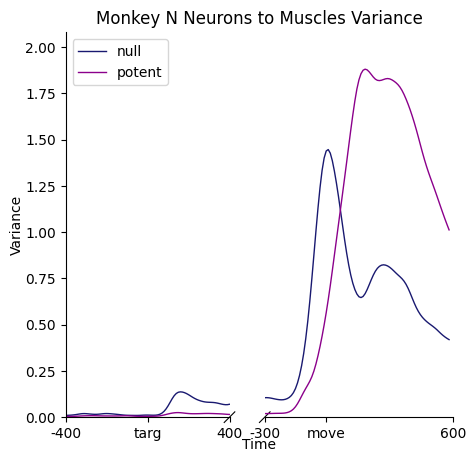

In [4]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor)

[19 24  6 21 10 13 17  0 16  8 23 26 11 18  2 25 12  3 22 14  9  5]
>>> best_lam returning: 7.017038286703837
frac null:  0.598009653753752
frac potent:  0.4019903462462474


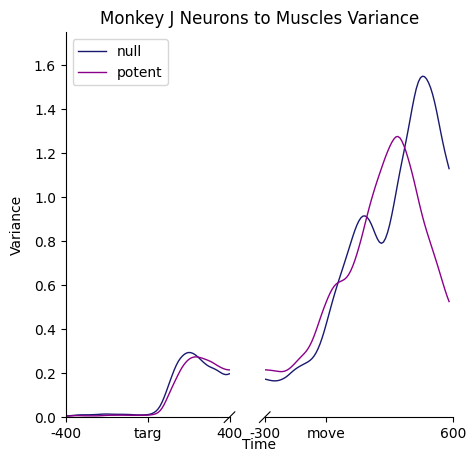

In [21]:
pcar.sup_tuning(J_ntm_tensor, J_mus_tensor)

# best lam = 100

[18 19 23 11  4 14  6 10 26  3  8  7  5  0 22 17 24 15 12  1  2 20]
>>> best_lam returning: 11.937766417144381
frac null:  0.5706484218053779
frac potent:  0.4293515781946236


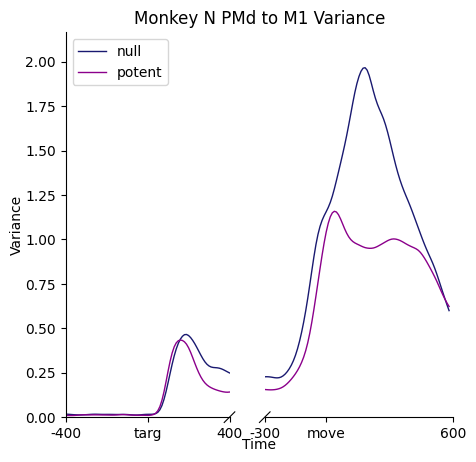

In [6]:
pcar.sup_tuning(N_PMd_tensor, N_M1_tensor, dims = 14) 

# best lam = 58.780160722749116

[ 9 19  0  1 12 10 24 22 18 14 25  6  2  8 20  3  7 26  4 15 23 11]
>>> best_lam returning: 20.30917620904739
[ 0 14  1 15 12  3 25  8 24 13 20  6 11 17 10 21 23 22  9  5 19]
>>> best_lam returning: 20.30917620904739
[ 5 10 19 16 11  0 12 21  7 20  8 22 14 23 17  1 18  6  3 13]
>>> best_lam returning: 11.937766417144381
[ 9  6  2 17 16  4  7 14  3 19 11 20  1  8  5  0 12]
>>> best_lam returning: 20.30917620904739
frac null:  0.5971286070776322
frac potent:  0.4028713929223682


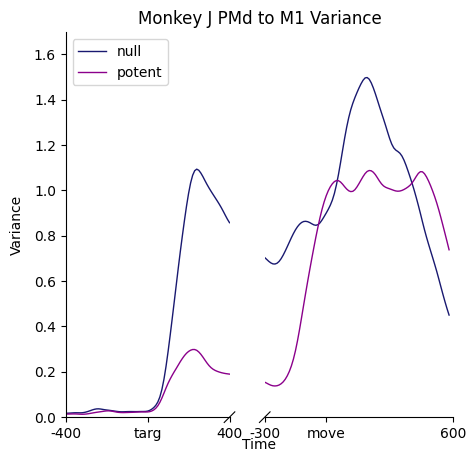

In [7]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[25 20 12 10  9 21 11  5  6  7 19 16 24 17  8 26 22 14 13  3 23  1]
>>> best_lam returning: 11.937766417144381
[23  7 12  5 18 17 19 20 16 24  1  9 25  6 10  2 15  8  0 21  3]
>>> best_lam returning: 11.937766417144381
[ 3 15  5  7 21 22 11 18  4 12 23  8 19  9 13 20 16  1 14  2]
>>> best_lam returning: 11.937766417144381
[ 7 17  3  4 19 10  0  9 15  1 13  2 18  5 11 20 12]
>>> best_lam returning: 11.937766417144381
frac null:  0.6029539916500103
frac potent:  0.3970460083499898


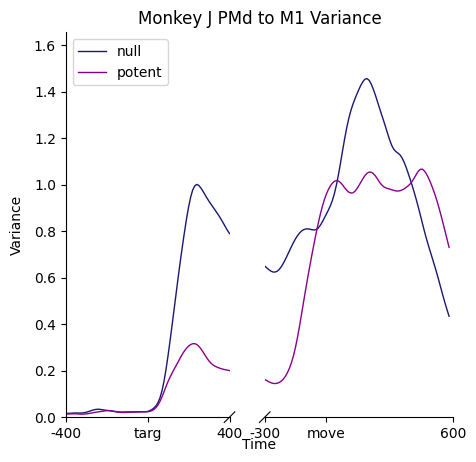

In [8]:
pcar.sup_tuning(J_PMd_tensor, J_M1_tensor, dims = 14)

[ 9  0 14  5 21 10  6 20 12 11 17 18  2 16 13 23 26 24  8 19 15  4]
>>> best_lam returning: 11.937766417144381
frac null:  0.7680439155061296
frac potent:  0.2319560844938707


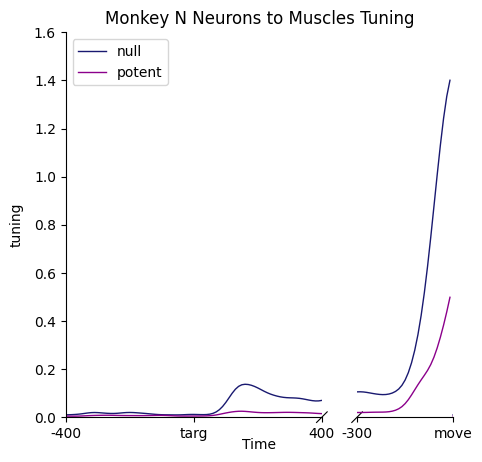

In [9]:
pcar.sup_tuning(N_all_tensor, N_mus_tensor, fig_4D = True)

In [10]:
def fig4_d (tensor_N, tensor_M, dims):

    
    # retrieving dataset specifications 
    J, PMd = pcar.ident(tensor_N)

    # getting weights matrix for potent and null space 
    cond, _, fin_time = tensor_N.shape
    regress_N, _, _ = pcar.time_shift(tensor_N, tensor_M, fig4 = True)
    N_tilde, _, _ = pcar.run_PCA(regress_N, dims)
    W_potent, W_null = pcar.tuning_setup(tensor_N, tensor_M, dims, time = True)
    
    # projecting the neural activity of 400ms before and after target and 300ms before and 800ms after move starts onto the potent and null space of the weights matrix
    N_potent = N_tilde @ W_potent
    N_null = N_tilde @ W_null

    # reshaping into a tensor 
    pot_tensor = pcar.shape_tensor(N_potent, cond)
    null_tensor = pcar.shape_tensor(N_null, cond)
    _, _, time = pot_tensor.shape

    # initializing array for holding the variance 
    V_pot = np.zeros(time)
    V_null = np.zeros(time)
    _, _, time = null_tensor.shape

    ratio = np.zeros(time)

    for t in range(time):

        Xn = null_tensor[:,:,t]
        Xp = pot_tensor[:,:,t]

        # subtract condition mean
        Xn -= Xn.mean(axis=0, keepdims=True)
        Xp -= Xp.mean(axis=0, keepdims=True)

        V_null = np.sum(Xn**2)
        V_pot  = np.sum(Xp**2)

        ratio[t] = (1/gamma) * (V_null / V_pot)